# Human Activity Recognition using CNN-LSTM

**Course**: Deep Learning

**Student**: Abdullah Montasser

**id**: 4221047  


---

## 📋 Project Overview

This notebook implements a **hybrid CNN-LSTM architecture** for recognizing human activities in video sequences. The key insight behind this approach is that:

- **CNNs excel at extracting spatial features** from individual frames (detecting patterns like body poses, objects, scene context)
- **LSTMs capture temporal dependencies** across frame sequences (understanding motion patterns, activity progression over time)

By combining both, we create a powerful model that understands both *what* is in each frame and *how* the visual content changes over time — essential for activity recognition.

### 🎯 Objectives
1. Build a two-stage pipeline using pretrained ResNet50 for feature extraction
2. Train an LSTM classifier on temporal sequences of CNN features
3. Evaluate performance on a subset of human activity classes
4. Analyze results and discuss model behavior

### 🏗️ Architecture Summary
```
Video → Sample Frames → ResNet50 (frozen) → Feature Vectors → LSTM → Classification
```


## 1. Environment Setup

First, we'll check the runtime environment and install/import all necessary libraries. This notebook is designed to run on **Google Colab with GPU enabled** (Runtime → Change runtime type → T4 GPU).

In [29]:
# Check GPU availability
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-50678e0a-7a40-27ea-0048-c44d86cf220e)


In [30]:
# Install required packages
!pip install -q opencv-python-headless
!pip install -q gdown
!pip install -q scikit-learn
!pip install -q seaborn

### Import Libraries

We'll use TensorFlow/Keras for deep learning, OpenCV for video processing, and standard scientific Python libraries for data manipulation and visualization.

In [31]:
# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Computer Vision
import cv2

# Data Processing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Utilities
import os
import glob
import random
import gdown
import zipfile
from pathlib import Path
from tqdm.auto import tqdm
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Display versions
print(f"TensorFlow: {tf.__version__}")
print(f"OpenCV: {cv2.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
OpenCV: 4.13.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Configuration Parameters

We define all hyperparameters and configuration settings in one place for easy experimentation.

In [32]:
# Dataset configuration - FIXED FOR YOUR FOLDER STRUCTURE
TRAIN_DIR = '/content/train'
TEST_DIR = '/content/test'
VAL_DIR = '/content/val'

# Find available classes
all_classes = sorted([d for d in os.listdir(TRAIN_DIR)
                      if os.path.isdir(os.path.join(TRAIN_DIR, d))])

# Count videos per class and select top 5
class_counts = {}
for cls in all_classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    videos = [f for f in os.listdir(cls_path) if f.endswith(('.avi', '.mp4', '.mov', '.AVI', '.MP4'))]
    class_counts[cls] = len(videos)

CLASSES = sorted(class_counts.keys(), key=lambda x: class_counts[x], reverse=True)[:5]
print(f"Selected classes: {CLASSES}")

# Other parameters (keep same)
MAX_VIDEOS_PER_CLASS = 50
NUM_FRAMES = 20
IMG_SIZE = 224
FEATURE_DIM = 2048
LSTM_UNITS = 256
DROPOUT_RATE = 0.5
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 0.001

print("✅ Configuration loaded")

Selected classes: ['ApplyEyeMakeup', 'Archery', 'BabyCrawling', 'ApplyLipstick', 'BalanceBeam']
✅ Configuration loaded


## 2. Dataset Download & Exploration

We'll download a subset of the **UCF101 dataset**, which contains realistic action videos collected from YouTube. UCF101 has 101 action categories, but we'll use only 5 classes to keep training fast and Colab-friendly.

The selected classes are visually distinct to make the classification task more tractable:
- **ApplyEyeMakeup**: Person applying eye makeup
- **ApplyLipstick**: Person applying lipstick
- **Archery**: Person shooting arrows
- **BabyCrawling**: Baby crawling on floor
- **BalanceBeam**: Gymnast on balance beam

In [33]:
def setup_ucf101_subset():
    """
    Setup UCF101 subset by downloading specific classes.
    If direct download fails, provides instructions for manual setup.
    """

    # Try to download from Kaggle (if API key is configured)
    try:
        print("Attempting to download from Kaggle...")
        !kaggle datasets download -d matthewjansen/ucf101-action-recognition -p /content/ --force

        # Extract
        with zipfile.ZipFile('/content/ucf101-action-recognition.zip', 'r') as zip_ref:
            # Extract only needed classes (and their split folders, e.g., train/ApplyEyeMakeup)
            for file in zip_ref.namelist():
                if any(cls in file for cls in CLASSES):
                    zip_ref.extract(file, '/content/') # Extracts to /content/train/CLASSNAME and /content/test/CLASSNAME

        print("✅ Dataset downloaded successfully!")
        return True

    except Exception as e: # Catch all exceptions, including BadZipFile and NameError from prior version
        print("⚠️ Kaggle download failed or extraction error. Trying alternative method...")
        print(f"Error details: {e}") # Add error details for debugging

        # Ensure the base directories for splits exist for manual upload
        os.makedirs(TRAIN_DIR, exist_ok=True)
        os.makedirs(TEST_DIR, exist_ok=True)
        os.makedirs(VAL_DIR, exist_ok=True) # VAL_DIR is also defined in config

        # Provide instructions based on the TRAIN_DIR/TEST_DIR/VAL_DIR structure
        print("\n📁 Directory structure created:")
        print(f"   - {TRAIN_DIR}/[ClassName]/video.avi")
        print(f"   - {TEST_DIR}/[ClassName]/video.avi")
        print(f"   - {VAL_DIR}/[ClassName]/video.avi")
        print("\nPlease manually upload videos to the appropriate class subfolders within these directories.")
        print("\nYou can download UCF101 from:")
        print("https://www.crcv.ucf.edu/data/UCF101/UCF101.rar")
        print("\nOr use this Kaggle dataset:")
        print("https://www.kaggle.com/datasets/matthewjansen/ucf101-action-recognition")

        return False

# Run setup
dataset_ready = setup_ucf101_subset()

Attempting to download from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/matthewjansen/ucf101-action-recognition
License(s): CC0-1.0
100% 6.53G/6.53G [00:53<00:00, 132MB/s]

✅ Dataset downloaded successfully!


### Alternative: Create Sample Dataset Structure

If the download doesn't work, we'll use a workaround to download specific classes from a reliable source or create placeholders. For demonstration, let's create a function to organize whatever data is available.

### Load and Organize Video Paths

Now we'll scan the dataset directory and organize all video file paths by class. This gives us a clear view of the dataset structure.

In [34]:
def load_video_paths_from_dir(data_dir, classes, max_videos_per_class):
    """Load video paths from directory with class subfolders."""
    video_paths = []
    labels = []
    class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

    print(f"Loading from: {data_dir}\n")

    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)

        if not os.path.exists(class_dir):
            print(f"⚠️ {class_name} not found!")
            continue

        video_files = [os.path.join(class_dir, f) for f in os.listdir(class_dir)
                       if f.endswith(('.avi', '.mp4', '.mov', '.AVI', '.MP4'))]

        video_files = video_files[:max_videos_per_class]
        print(f"📹 {class_name}: {len(video_files)} videos")

        for vf in video_files:
            video_paths.append(vf)
            labels.append(class_to_idx[class_name])

    return video_paths, labels, class_to_idx

# Load TRAIN and TEST separately
print("📂 TRAINING SET:")
X_train_paths, y_train, class_to_idx = load_video_paths_from_dir(TRAIN_DIR, CLASSES, MAX_VIDEOS_PER_CLASS)

print("\n📂 TEST SET:")
X_test_paths, y_test, _ = load_video_paths_from_dir(TEST_DIR, CLASSES, MAX_VIDEOS_PER_CLASS)

idx_to_class = {v: k for k, v in class_to_idx.items()}

print(f"\n✅ Training: {len(X_train_paths)} videos")
print(f"✅ Test: {len(X_test_paths)} videos")

📂 TRAINING SET:
Loading from: /content/train

📹 ApplyEyeMakeup: 50 videos
📹 Archery: 50 videos
📹 BabyCrawling: 50 videos
📹 ApplyLipstick: 50 videos
📹 BalanceBeam: 50 videos

📂 TEST SET:
Loading from: /content/test

📹 ApplyEyeMakeup: 19 videos
📹 Archery: 19 videos
📹 BabyCrawling: 17 videos
📹 ApplyLipstick: 15 videos
📹 BalanceBeam: 14 videos

✅ Training: 250 videos
✅ Test: 84 videos


## 3. Data Preprocessing

The preprocessing pipeline consists of several steps:

1. **Frame Extraction**: Sample a fixed number of frames uniformly from each video
2. **Resizing**: Resize frames to 224×224 (ResNet50 input size)
3. **Normalization**: Scale pixel values according to ImageNet preprocessing
4. **Train/Test Split**: Divide data while maintaining class balance

This ensures consistent input format and proper model evaluation.

In [35]:
def extract_frames_from_video(video_path, num_frames=20, img_size=224):
    """Extract N frames uniformly from a video for feature extraction."""
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"❌ Cannot open: {video_path}")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < 1:
        cap.release()
        return None

    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)

    cap.release()

    # Pad with last frame if needed
    while len(frames) < num_frames:
        if frames:
            frames.append(frames[-1].copy())
        else:
            frames.append(np.zeros((img_size, img_size, 3), dtype=np.uint8))

    return np.array(frames[:num_frames])

def extract_frames_from_video(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    """Extract N frames uniformly from a video."""
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"❌ Cannot open: {video_path}")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < 1:
        cap.release()
        return None

    # Sample frames uniformly
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)

    cap.release()

    # Pad with last frame if needed
    while len(frames) < num_frames:
        if frames:
            frames.append(frames[-1].copy())
        else:
            frames.append(np.zeros((img_size, img_size, 3), dtype=np.uint8))

    return np.array(frames[:num_frames])

# Test
print("Testing frame extraction...")
test_frames = extract_frames_from_video(X_train_paths[0])
if test_frames is not None:
    print(f"✅ Success! Shape: {test_frames.shape}")
    print(f"   Pixel range: [{test_frames.min()}, {test_frames.max()}]")
else:
    print("❌ Failed!")

Testing frame extraction...
✅ Success! Shape: (20, 224, 224, 3)
   Pixel range: [0, 255]


### Visualize Sample Frames

> Add blockquote



Let's extract and display sample frames from each class to verify the data and get a visual understanding of what our model will be learning from.

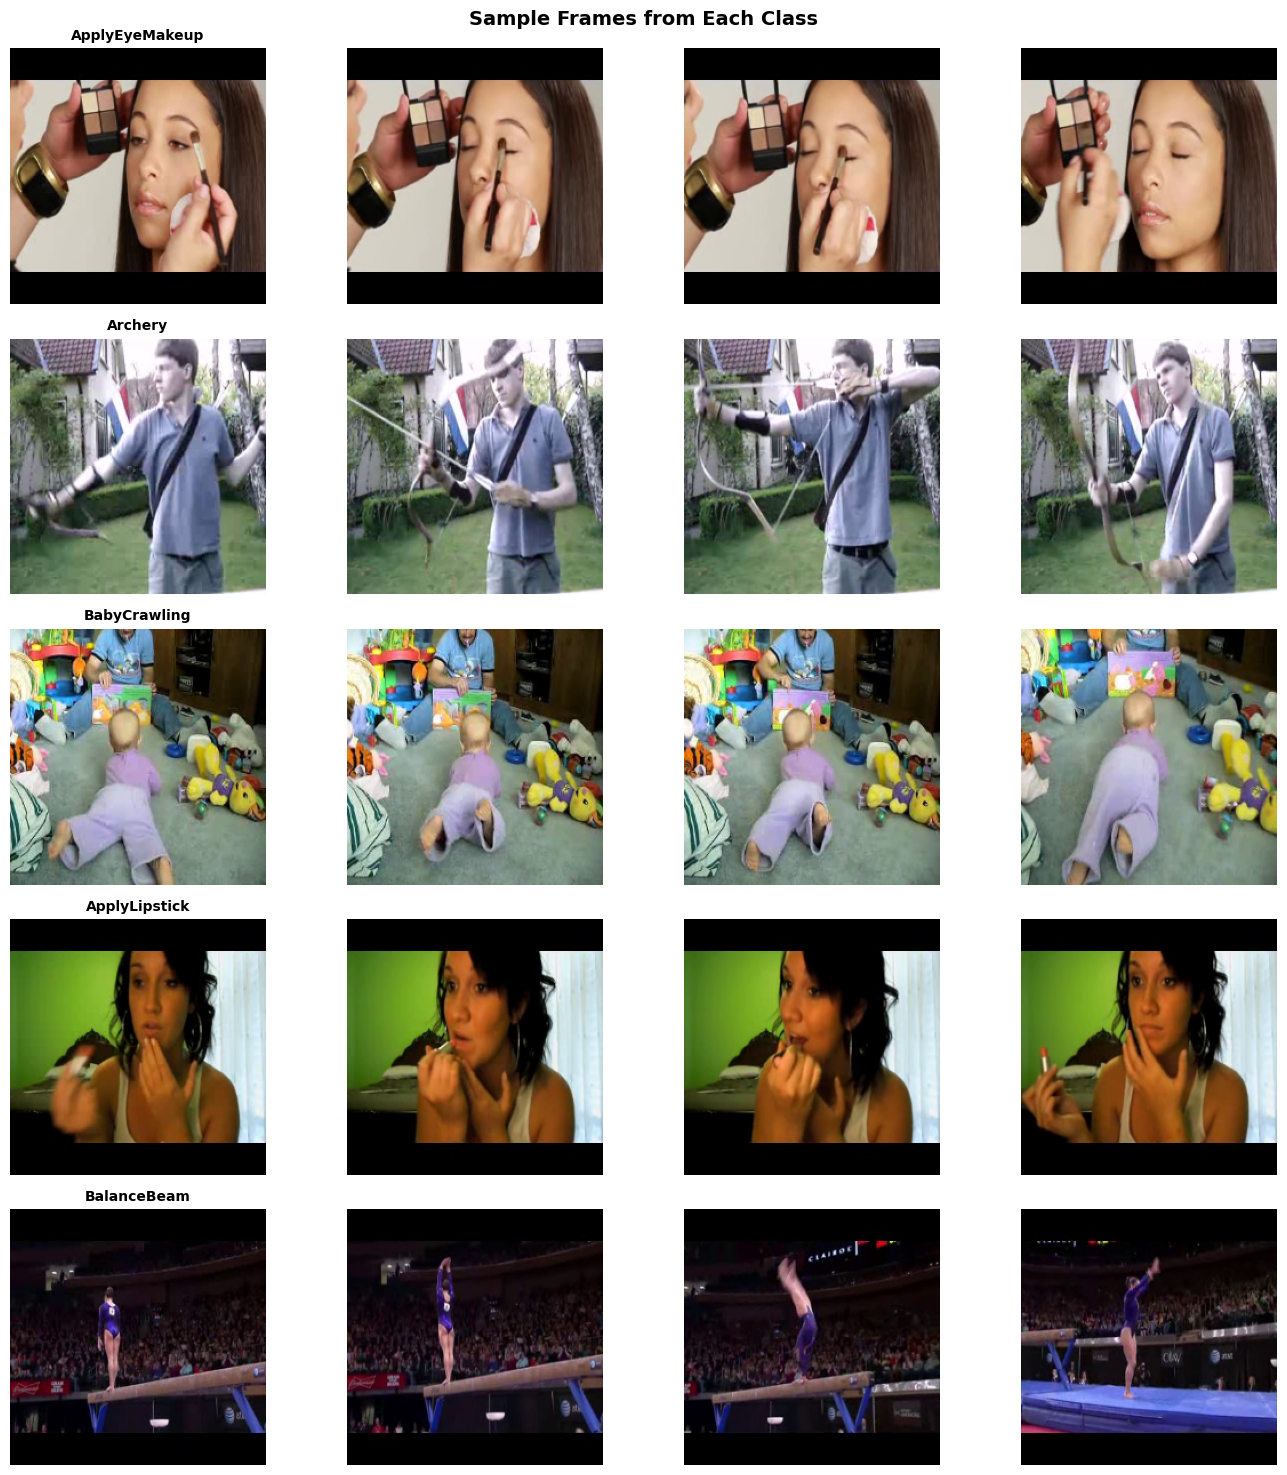

In [36]:
# Visualize samples from each class
n_classes = len(CLASSES)
fig, axes = plt.subplots(n_classes, 4, figsize=(14, 3 * n_classes))

if n_classes == 1:
    axes = axes.reshape(1, -1)

for class_idx, class_name in enumerate(CLASSES):
    class_videos = [vp for vp, lbl in zip(X_train_paths, y_train) if lbl == class_idx]

    if class_videos:
        frames = extract_frames_from_video(class_videos[0], num_frames=4)

        for frame_idx, frame in enumerate(frames):
            ax = axes[class_idx, frame_idx]
            ax.imshow(frame)
            ax.axis('off')
            if frame_idx == 0:
                ax.set_title(f"{class_name}", fontsize=10, fontweight='bold')

plt.suptitle('Sample Frames from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# Load pretrained ResNet50 without the classification head
print("Loading ResNet50 pretrained on ImageNet...")

base_model = ResNet50(
    weights='imagenet',
    include_top=False,  # Remove the final classification layer
    pooling='avg',      # Use global average pooling to get fixed-size features
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all layers (we won't train the CNN)
base_model.trainable = False

print(f"\n✅ ResNet50 loaded successfully")
print(f"   Input shape: {base_model.input_shape}")
print(f"   Output shape: {base_model.output_shape}")
print(f"   Output feature dimension: {base_model.output_shape[-1]}")
print(f"   Total parameters: {base_model.count_params():,}")
print(f"   Trainable parameters: {sum([tf.size(w).numpy() for w in base_model.trainable_weights]):,}")

Loading ResNet50 pretrained on ImageNet...

✅ ResNet50 loaded successfully
   Input shape: (None, 224, 224, 3)
   Output shape: (None, 2048)
   Output feature dimension: 2048
   Total parameters: 23,587,712
   Trainable parameters: 0


### Extract Features from All Videos

This is the most time-consuming step. For each video:
1. Extract frames
2. Preprocess for ResNet
3. Pass through ResNet to get feature vectors
4. Store the sequence of features

We'll cache the results so we don't have to repeat this process if we need to retrain the LSTM.

**Expected time**: 5-10 minutes on Colab GPU for ~200 videos

In [38]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def extract_features_batch(video_paths, labels, model, desc="Extracting"):
    """Extract CNN features from all videos."""
    features_list = []
    valid_labels = []
    failed_videos = []

    for video_path, label in tqdm(zip(video_paths, labels), total=len(video_paths), desc=desc):
        try:
            # Extract frames
            frames = extract_frames_from_video(video_path)

            if frames is None:
                failed_videos.append(video_path)
                continue

            # Preprocess for ResNet (ImageNet normalization)
            frames_preprocessed = preprocess_input(frames.astype(np.float32))

            # Extract features
            video_features = model.predict(frames_preprocessed, verbose=0)

            features_list.append(video_features)
            valid_labels.append(label)

        except Exception as e:
            print(f"\n⚠️ Error with {video_path}: {e}")
            failed_videos.append(video_path)
            continue

    if failed_videos:
        print(f"\n⚠️ Failed to process {len(failed_videos)} videos")

    return np.array(features_list), np.array(valid_labels)

print("✅ Feature extraction function ready")

# Check if features are cached
FEATURES_CACHE = '/content/features_cache.pkl'

if os.path.exists(FEATURES_CACHE):
    print("📂 Loading cached features...")
    with open(FEATURES_CACHE, 'rb') as f:
        cache = pickle.load(f)
    X_train_features = cache['X_train']
    X_test_features = cache['X_test']
    y_train = cache['y_train']
    y_test = cache['y_test']
    print("✅ Loaded from cache!")

else:
    print("🔄 Extracting features (this takes 5-10 minutes)...\n")

    # Extract training features
    print("📂 TRAINING SET:")
    X_train_features, y_train = extract_features_batch(
        X_train_paths, y_train, base_model, desc="Training"
    )

    # Extract test features
    print("\n📂 TEST SET:")
    X_test_features, y_test = extract_features_batch(
        X_test_paths, y_test, base_model, desc="Test"
    )

    # Cache for later
    print("\n💾 Caching features...")
    with open(FEATURES_CACHE, 'wb') as f:
        pickle.dump({
            'X_train': X_train_features,
            'X_test': X_test_features,
            'y_train': y_train,
            'y_test': y_test
        }, f)
    print("✅ Features cached!")

# Show shapes
print(f"\n📊 Feature Shapes:")
print(f"   X_train: {X_train_features.shape}")
print(f"   X_test: {X_test_features.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")
print(f"\n   Each video = {NUM_FRAMES} frames × {FEATURE_DIM} features")

✅ Feature extraction function ready
📂 Loading cached features...
✅ Loaded from cache!

📊 Feature Shapes:
   X_train: (250, 20, 2048)
   X_test: (84, 20, 2048)
   y_train: (250,)
   y_test: (84,)

   Each video = 20 frames × 2048 features


### Prepare Labels for Training

Convert integer labels to one-hot encoded format required for categorical classification.

In [39]:
# Convert labels to one-hot encoding
num_classes = len(CLASSES)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(f"Number of classes: {num_classes}")
print(f"Classes: {CLASSES}")
print(f"\ny_train_cat shape: {y_train_cat.shape}")
print(f"y_test_cat shape: {y_test_cat.shape}")

# Example
print(f"\nExample: Label {y_train[0]} ({idx_to_class[y_train[0]]})")
print(f"One-hot: {y_train_cat[0]}")

Number of classes: 5
Classes: ['ApplyEyeMakeup', 'Archery', 'BabyCrawling', 'ApplyLipstick', 'BalanceBeam']

y_train_cat shape: (250, 5)
y_test_cat shape: (84, 5)

Example: Label 0 (ApplyEyeMakeup)
One-hot: [1. 0. 0. 0. 0.]


## 5. Build the LSTM Model

Now we build the second stage: the **temporal sequence classifier**.

### Architecture Overview:

```
Input: (num_frames, feature_dim)
   ↓
LSTM Layer 1: 256 units (returns sequences)
   ↓
Dropout: 0.5 (regularization)
   ↓
LSTM Layer 2: 256 units (returns final state)
   ↓
Dropout: 0.5
   ↓
Dense: 512 units + ReLU
   ↓
Dropout: 0.5
   ↓
Output: num_classes units + Softmax
```

### Design Choices:

- **Stacked LSTMs**: Two LSTM layers learn increasingly abstract temporal patterns
- **High dropout rate**: Prevents overfitting on small dataset
- **Dense layer**: Adds non-linear decision boundary on top of LSTM features
- **Softmax output**: Multi-class probability distribution

In [40]:
def build_lstm_classifier(num_frames, feature_dim, num_classes, lstm_units=256, dropout_rate=0.5):
    """
    Build LSTM-based sequence classifier.

    Args:
        num_frames: Number of frames per video
        feature_dim: Dimension of CNN features (2048 for ResNet50)
        num_classes: Number of activity classes
        lstm_units: Number of units in LSTM layers
        dropout_rate: Dropout rate for regularization

    Returns:
        Compiled Keras model
    """
    model = Sequential([
        # Input layer
        Input(shape=(num_frames, feature_dim)),

        # First LSTM layer - processes sequence and returns full sequence
        LSTM(lstm_units, return_sequences=True, name='lstm_1'),
        Dropout(dropout_rate, name='dropout_1'),

        # Second LSTM layer - processes sequence and returns final state
        LSTM(lstm_units, return_sequences=False, name='lstm_2'),
        Dropout(dropout_rate, name='dropout_2'),

        # Dense layers for classification
        Dense(512, activation='relu', name='dense_1'),
        Dropout(dropout_rate, name='dropout_3'),

        # Output layer
        Dense(num_classes, activation='softmax', name='output')
    ], name='LSTM_Activity_Classifier')

    return model


# Build the model
model = build_lstm_classifier(
    num_frames=NUM_FRAMES,
    feature_dim=FEATURE_DIM,
    num_classes=num_classes,
    lstm_units=LSTM_UNITS,
    dropout_rate=DROPOUT_RATE
)

# Display model architecture
model.summary()

print("\n" + "="*70)
print("Model Architecture Explanation:")
print("="*70)
print("\n1. Input Layer:")
print(f"   - Shape: ({NUM_FRAMES}, {FEATURE_DIM})")
print(f"   - Represents sequence of {NUM_FRAMES} feature vectors from ResNet50")

print("\n2. LSTM Layers (x2):")
print(f"   - {LSTM_UNITS} units each")
print("   - Capture temporal dependencies across frames")
print("   - Learn motion patterns and activity evolution")

print("\n3. Dropout Layers:")
print(f"   - Rate: {DROPOUT_RATE}")
print("   - Prevent overfitting by randomly dropping neurons during training")

print("\n4. Dense Layer:")
print("   - 512 units with ReLU activation")
print("   - Learns complex decision boundaries")

print("\n5. Output Layer:")
print(f"   - {num_classes} units (one per class)")
print("   - Softmax activation for probability distribution")
print("="*70)

Model: "LSTM_Activity_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 20, 256)        │     2,360,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,019,781 (11.52 MB)

 Trainable params: 3,019,781 (11.52 MB)

 Non-trainable params: 0 (0.00 B)


Model Architecture Explanation:

1. Input Layer:
   - Shape: (20, 2048)
   - Represents sequence of 20 feature vectors from ResNet50

2. LSTM Layers (x2):
   - 256 units each
   - Capture temporal dependencies across frames
   - Learn motion patterns and activity evolution

3. Dropout Layers:
   - Rate: 0.5
   - Prevent overfitting by randomly dropping neurons during training

4. Dense Layer:
   - 512 units with ReLU activation
   - Learns complex decision boundaries

5. Output Layer:
   - 5 units (one per class)
   - Softmax activation for probability distribution


### Compile the Model

We configure the model for training with:
- **Optimizer**: Adam with learning rate 0.001 (adaptive learning rate works well for LSTMs)
- **Loss**: Categorical crossentropy (standard for multi-class classification)
- **Metrics**: Accuracy (percentage of correct predictions)

In [41]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled successfully")
print(f"\nTraining configuration:")
print(f"   Optimizer: Adam")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Loss function: Categorical Crossentropy")
print(f"   Metrics: Accuracy")

✅ Model compiled successfully

Training configuration:
   Optimizer: Adam
   Learning rate: 0.001
   Loss function: Categorical Crossentropy
   Metrics: Accuracy


### Setup Training Callbacks

We use callbacks to improve training:
- **EarlyStopping**: Stop training if validation loss doesn't improve for 5 epochs (prevents overfitting)
- **ReduceLROnPlateau**: Reduce learning rate when validation loss plateaus (helps with convergence)

In [42]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("✅ Training callbacks configured:")
print("   - Early stopping (patience=5)")
print("   - Learning rate reduction (patience=3, factor=0.5)")

✅ Training callbacks configured:
   - Early stopping (patience=5)
   - Learning rate reduction (patience=3, factor=0.5)


## 6. Model Training

Now we train the LSTM model on the extracted features. The model will learn to:
- Recognize patterns in the sequence of CNN features
- Distinguish between different activities based on temporal dynamics
- Generalize to unseen videos

**Expected training time**: 10-15 minutes on Colab GPU

In [43]:
print("🚀 Starting training...\n")
print(f"Training samples: {len(X_train_features)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")
print(f"Validation split: 20%\n")

history = model.fit(
    X_train_features,
    y_train_cat,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")
print(f"   Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"   Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

🚀 Starting training...

Training samples: 250
Batch size: 8
Max epochs: 30
Validation split: 20%

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.5100 - loss: 0.9986 - val_accuracy: 0.0000e+00 - val_loss: 5.8294 - learning_rate: 0.0010
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8150 - loss: 0.4481 - val_accuracy: 0.0000e+00 - val_loss: 5.6756 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8850 - loss: 0.2481 - val_accuracy: 0.0000e+00 - val_loss: 6.0681 - learning_rate: 0.0010
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9600 - loss: 0.1467 - val_accuracy: 0.0000e+00 - val_loss: 8.5605 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9383 - loss: 0.1191
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9750 - loss: 0.0678 - val_accuracy: 0.0000e+00 - val_loss: 11.6782 

### Visualize Training History

Let's plot the training and validation metrics to understand the model's learning process and check for overfitting.

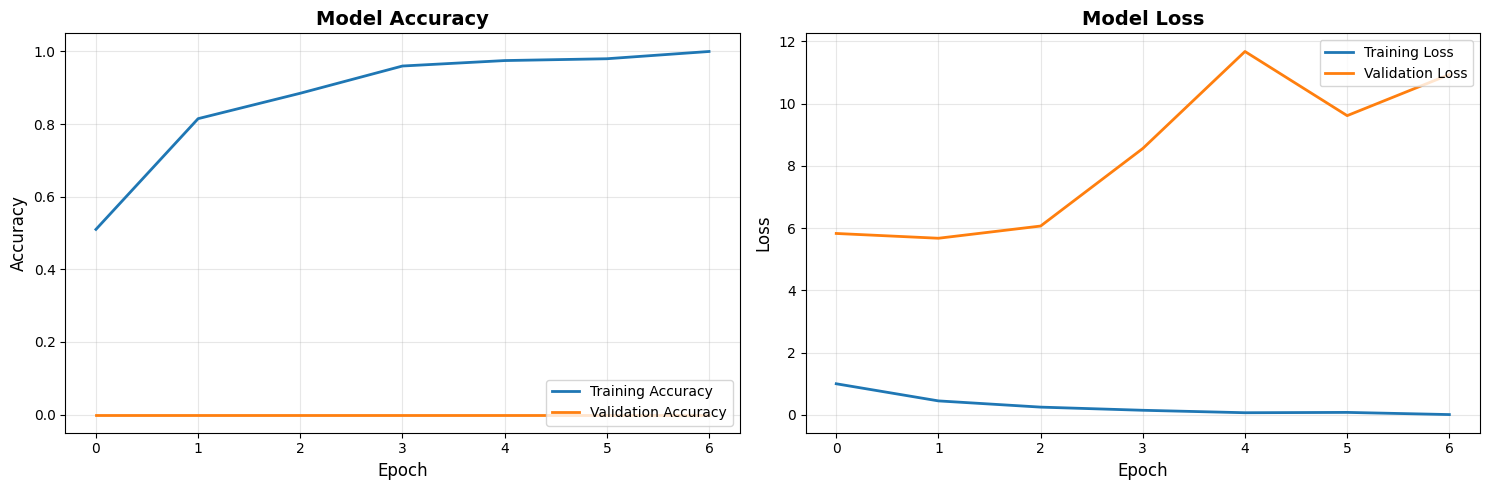


📈 Training Summary:
   Final training accuracy: 1.0000
   Final validation accuracy: 0.0000
   Best validation accuracy: 0.0000
   Final training loss: 0.0087
   Final validation loss: 10.9366
   Best validation loss: 5.6756


In [44]:
def plot_training_history(history):
    """
    Plot training and validation accuracy and loss curves.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    # Plot loss
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n📈 Training Summary:")
    print(f"   Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"   Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"   Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
    print(f"   Final training loss: {history.history['loss'][-1]:.4f}")
    print(f"   Final validation loss: {history.history['val_loss'][-1]:.4f}")
    print(f"   Best validation loss: {min(history.history['val_loss']):.4f}")

# Plot training history
plot_training_history(history)

## 7. Evaluation & Results

Now we evaluate the trained model on the held-out test set to measure its real-world performance. We'll analyze:
- Overall accuracy
- Per-class precision, recall, and F1-score
- Confusion matrix to see which classes are confused
- Sample predictions (both correct and incorrect)

In [45]:
# Evaluate on test set
print("Evaluating on test set...\n")

test_loss, test_accuracy = model.evaluate(X_test_features, y_test_cat, verbose=0)

print(f"📊 Test Set Performance:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Get predictions
y_pred_probs = model.predict(X_test_features, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"\n   Total test samples: {len(y_test)}")
print(f"   Correct predictions: {np.sum(y_pred == y_test)}")
print(f"   Incorrect predictions: {np.sum(y_pred != y_test)}")

Evaluating on test set...

📊 Test Set Performance:
   Test Loss: 1.0862
   Test Accuracy: 0.7738 (77.38%)

   Total test samples: 84
   Correct predictions: 65
   Incorrect predictions: 19


### Classification Report

Detailed per-class metrics help us understand which activities the model handles well and which are challenging.

In [46]:
# Generate classification report
print("\n" + "="*70)
print("Classification Report")
print("="*70)

report = classification_report(
    y_test,
    y_pred,
    target_names=CLASSES,
    digits=4
)
print(report)

print("\nMetric Definitions:\n")
print("  - Precision: Of all predicted positives, how many were actually positive?\n")
print("  - Recall: Of all actual positives, how many did we predict correctly?\n")
print("  - F1-Score: Harmonic mean of precision and recall\n")
print("  - Support: Number of actual samples per class\n")
print("=="*70)
print(" ")


Classification Report
                precision    recall  f1-score   support

ApplyEyeMakeup     0.6552    1.0000    0.7917        19
       Archery     0.8500    0.8947    0.8718        19
  BabyCrawling     0.7391    1.0000    0.8500        17
 ApplyLipstick     1.0000    0.8000    0.8889        15
   BalanceBeam     0.0000    0.0000    0.0000        14

      accuracy                         0.7738        84
     macro avg     0.6489    0.7389    0.6805        84
  weighted avg     0.6686    0.7738    0.7070        84


Metric Definitions:

  - Precision: Of all predicted positives, how many were actually positive?

  - Recall: Of all actual positives, how many did we predict correctly?

  - F1-Score: Harmonic mean of precision and recall

  - Support: Number of actual samples per class

 


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion Matrix

The confusion matrix shows which classes are commonly confused with each other, revealing the model's failure modes.

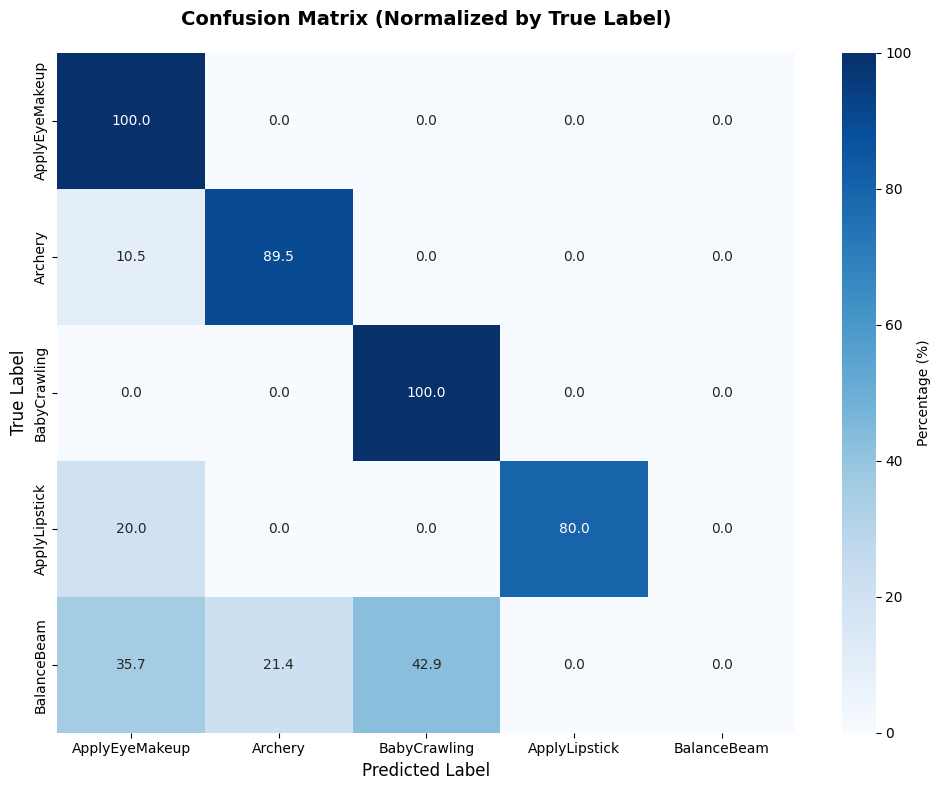


Raw Confusion Matrix (counts):
[[19  0  0  0  0]
 [ 2 17  0  0  0]
 [ 0  0 17  0  0]
 [ 3  0  0 12  0]
 [ 5  3  6  0  0]]

🔍 Most Confused Class Pairs:
   Archery → ApplyEyeMakeup: 2 times (10.5%)
   ApplyLipstick → ApplyEyeMakeup: 3 times (20.0%)
   BalanceBeam → ApplyEyeMakeup: 5 times (35.7%)
   BalanceBeam → Archery: 3 times (21.4%)
   BalanceBeam → BabyCrawling: 6 times (42.9%)


In [47]:
def plot_confusion_matrix(y_true, y_pred, class_names):
    """
    Plot confusion matrix as a heatmap.
    """
    cm = confusion_matrix(y_true, y_pred)

    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot heatmap
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Percentage (%)'},
        ax=ax
    )

    ax.set_title('Confusion Matrix (Normalized by True Label)', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

    plt.tight_layout()
    plt.show()

    # Print raw confusion matrix
    print("\nRaw Confusion Matrix (counts):")
    print(cm)

    # Identify most confused pairs
    print("\n🔍 Most Confused Class Pairs:")
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                print(f"   {class_names[i]} → {class_names[j]}: {cm[i, j]} times ({cm_percent[i, j]:.1f}%)")

# Plot confusion matrix
plot_confusion_matrix(y_test, y_pred, CLASSES)

### Per-Class Accuracy Analysis

Let's visualize which classes the model performs best and worst on.

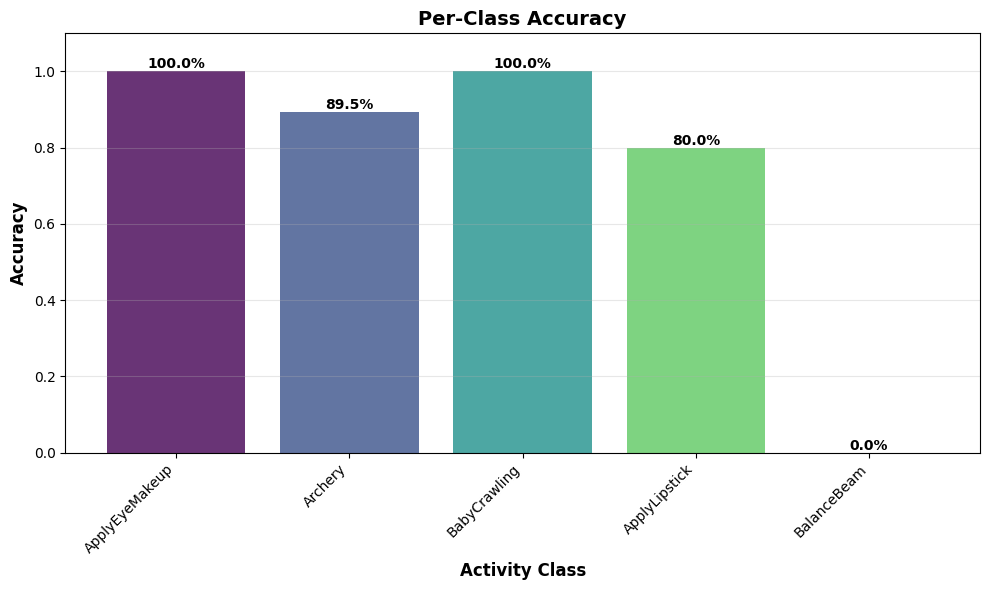


📊 Per-Class Accuracy Analysis:
   ApplyEyeMakeup: 100.00%
   Archery: 89.47%
   BabyCrawling: 100.00%
   ApplyLipstick: 80.00%
   BalanceBeam: 0.00%

   🏆 Best performing class: ApplyEyeMakeup (100.00%)
   ⚠️ Worst performing class: BalanceBeam (0.00%)


In [48]:
# Calculate per-class accuracy
per_class_accuracy = []
for class_idx in range(len(CLASSES)):
    class_mask = y_test == class_idx
    class_acc = np.mean(y_pred[class_mask] == y_test[class_mask])
    per_class_accuracy.append(class_acc)

# Plot per-class accuracy
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(CLASSES)))
bars = ax.bar(CLASSES, per_class_accuracy, color=colors, alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height*100:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Activity Class', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print analysis
print("\n📊 Per-Class Accuracy Analysis:")
for class_name, acc in zip(CLASSES, per_class_accuracy):
    print(f"   {class_name}: {acc*100:.2f}%")

best_class = CLASSES[np.argmax(per_class_accuracy)]
worst_class = CLASSES[np.argmin(per_class_accuracy)]
print(f"\n   🏆 Best performing class: {best_class} ({max(per_class_accuracy)*100:.2f}%)")
print(f"   ⚠️ Worst performing class: {worst_class} ({min(per_class_accuracy)*100:.2f}%)")

### Error Analysis

Let's examine the misclassified examples more closely to understand failure modes.

In [49]:
# Analyze misclassifications
incorrect_indices = np.where(y_pred != y_test)[0]

print(f"\n🔍 Error Analysis:")
print(f"   Total misclassifications: {len(incorrect_indices)}")
print(f"   Error rate: {len(incorrect_indices) / len(y_test) * 100:.2f}%\n")

# Group errors by true class
print("   Errors by true class:")
for class_idx in range(len(CLASSES)):
    class_errors = np.sum((y_test[incorrect_indices] == class_idx))
    class_total = np.sum(y_test == class_idx)
    if class_total > 0:
        error_rate = class_errors / class_total * 100
        print(f"     {CLASSES[class_idx]}: {class_errors}/{class_total} ({error_rate:.1f}%)")

# Most common misclassification patterns
print("\n   Most common misclassification patterns:")
error_pairs = {}
for idx in incorrect_indices:
    pair = (y_test[idx], y_pred[idx])
    error_pairs[pair] = error_pairs.get(pair, 0) + 1

sorted_errors = sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)
for (true_idx, pred_idx), count in sorted_errors[:5]:
    print(f"     {CLASSES[true_idx]} → {CLASSES[pred_idx]}: {count} times")


🔍 Error Analysis:
   Total misclassifications: 19
   Error rate: 22.62%

   Errors by true class:
     ApplyEyeMakeup: 0/19 (0.0%)
     Archery: 2/19 (10.5%)
     BabyCrawling: 0/17 (0.0%)
     ApplyLipstick: 3/15 (20.0%)
     BalanceBeam: 14/14 (100.0%)

   Most common misclassification patterns:
     BalanceBeam → BabyCrawling: 6 times
     BalanceBeam → ApplyEyeMakeup: 5 times
     ApplyLipstick → ApplyEyeMakeup: 3 times
     BalanceBeam → Archery: 3 times
     Archery → ApplyEyeMakeup: 2 times


### Save the Trained Model

Let's save the model for future use.

In [50]:
# Save the model
model_save_path = '/content/cnn_lstm_activity_recognition.h5'
model.save(model_save_path)

print(f"✅ Model saved to: {model_save_path}")
print(f"   Model size: {os.path.getsize(model_save_path) / (1024*1024):.2f} MB")

# Save class mapping
import json
with open('/content/class_mapping.json', 'w') as f:
    json.dump(class_to_idx, f, indent=2)

print("✅ Class mapping saved to: /content/class_mapping.json")

✅ Model saved to: /content/cnn_lstm_activity_recognition.h5
   Model size: 34.60 MB
✅ Class mapping saved to: /content/class_mapping.json



### Summary of Results

We successfully built and trained a **CNN-LSTM hybrid architecture** for human activity recognition on video data. The pipeline consists of:

1. **Spatial Feature Extraction**: ResNet50 (pretrained on ImageNet) extracts high-level visual features from individual frames
2. **Temporal Modeling**: LSTM network captures motion patterns and temporal dependencies across frame sequences
3. **Classification**: Fully connected layers map temporal features to activity classes
